# Data Science Challenge

In [1]:
# If additional packages are needed that are not installed by default, uncomment the last two lines of this 
# cell and replace <package list> with a list of additional packages.
# This will ensure the notebook has all the dependencies and works everywhere

#import sys
#!{sys.executable} -m pip install <package list>

In [1]:
#Libraries
import pandas as pd
pd.set_option("display.max_columns", 101)

In [117]:
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import scale
from sklearn.utils import shuffle
from sklearn.linear_model import LinearRegression
from sklearn import model_selection, metrics

## Data Description

Column | Description
:---|:---
`id` | Record index
`timestamp` | Datetime (YYYY:MM:DD HH AM/PM)
`season` | Season (spring, summer, fall, winter)
`holiday` | Whether day is a holiday or not (Yes or No)
`workingday` | Whether day is a working day or not (Yes or No)
`weather`| Weather condition (Clear or partly cloudy, Mist, Light snow or rain, heavy rain/ice pellets/ snow + fog 
`temp`| Average temperature recorded for the hour ( in degree Celsius)
`temp_feel`| Average feeling temperature recorded for the hour ( in degree Celsius)
`hum`| Average humidity recorded for the hour (in %)
`windspeed`| Average wind speed recorded for the hour (in miles/hour)
`demand`| Hourly count of bikes rented

## Data Wrangling & Visualization

In [156]:
# The dataset is already loaded below
data = pd.read_csv("train.csv")

In [157]:
data.head()

,id,timestamp,season,holiday,workingday,weather,temp,temp_feel,humidity,windspeed,demand
0,1,2017-01-01 00:00:00,spring,No,No,Clear or partly cloudy,9.84,14.395,81.0,0.0,2.772589
1,2,2017-01-01 01:00:00,spring,No,No,Clear or partly cloudy,9.02,13.635,80.0,0.0,3.688879
2,3,2017-01-01 02:00:00,spring,No,No,Clear or partly cloudy,9.02,13.635,80.0,0.0,3.465736
3,4,2017-01-01 03:00:00,spring,No,No,Clear or partly cloudy,9.84,14.395,75.0,0.0,2.564949
4,5,2017-01-01 04:00:00,spring,No,No,Clear or partly cloudy,9.84,14.395,75.0,0.0,0.000000


In [158]:
#Explore columns
data.columns

Index(['id', 'timestamp', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'temp_feel', 'humidity', 'windspeed', 'demand'],
      dtype='object')

In [159]:
#Description
data.describe()

,id,temp,temp_feel,humidity,windspeed,demand
count,8708.000000,7506.000000,8606.000000,8669.00000,8508.000000,8708.000000
mean,4354.500000,20.089454,23.531261,60.99354,13.048589,4.452725
std,2513.927405,8.023304,8.737997,19.67989,8.311058,1.493963
min,1.000000,0.820000,0.760000,0.00000,0.000000,0.000000
25%,2177.750000,13.940000,15.910000,46.00000,7.001500,3.637586
50%,4354.500000,20.500000,24.240000,60.00000,12.998000,4.867534
75%,6531.250000,26.240000,31.060000,77.00000,19.001200,5.556828
max,8708.000000,41.000000,45.455000,100.00000,56.996900,6.792344


In [160]:
# Let's check the dataframe for empty values.

In [161]:
data.isnull().any()

id            False
timestamp     False
season        False
holiday       False
workingday    False
weather       False
temp           True
temp_feel      True
humidity       True
windspeed      True
demand        False
dtype: bool

In [162]:
# Let's delete the rows with empty feature values (temp, temp_feel, humidity, windspeed) as non-informative.
# But first, let's count the number of such lines:

In [163]:
data.isnull().T.any().T.sum() 

1523

In [164]:
# Too much, of course, but what can you do...

In [165]:
data.dropna(inplace=True)
data

,id,timestamp,season,holiday,workingday,weather,temp,temp_feel,humidity,windspeed,demand
0,1,2017-01-01 00:00:00,spring,No,No,Clear or partly cloudy,9.84,14.395,81.0,0.0000,2.772589
1,2,2017-01-01 01:00:00,spring,No,No,Clear or partly cloudy,9.02,13.635,80.0,0.0000,3.688879
2,3,2017-01-01 02:00:00,spring,No,No,Clear or partly cloudy,9.02,13.635,80.0,0.0000,3.465736
3,4,2017-01-01 03:00:00,spring,No,No,Clear or partly cloudy,9.84,14.395,75.0,0.0000,2.564949
4,5,2017-01-01 04:00:00,spring,No,No,Clear or partly cloudy,9.84,14.395,75.0,0.0000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
8703,8704,2018-08-05 00:00:00,fall,No,No,Clear or partly cloudy,30.34,34.850,70.0,19.0012,5.030438
8704,8705,2018-08-05 01:00:00,fall,No,No,Clear or partly cloudy,30.34,34.850,70.0,16.9979,4.465908
8705,8706,2018-08-05 02:00:00,fall,No,No,Clear or partly cloudy,30.34,34.850,70.0,19.9995,4.290459
8706,8707,2018-08-05 03:00:00,fall,No,No,Clear or partly cloudy,29.52,34.850,74.0,16.9979,3.713572


In [86]:
# The dataset contains real, binary and ordinal features. To analyze them, we reduce them all to real form.
# To do this, we will use the LabelEncoder function from the sklearn.preprocessing library

In [166]:
le = LabelEncoder()

le.fit(data.season)
data['season_le'] = le.transform(data.season)

le.fit(data.holiday)
data['holiday_le'] = le.transform(data.holiday)

le.fit(data.workingday)
data['workingday_le'] = le.transform(data.workingday)

le.fit(data.weather)
data['weather_le'] = le.transform(data.weather)

data.drop(['id', 'timestamp', 'season', 'holiday', 'workingday', 'weather'], axis=1, inplace=True)

data

,temp,temp_feel,humidity,windspeed,demand,season_le,holiday_le,workingday_le,weather_le
0,9.84,14.395,81.0,0.0000,2.772589,1,0,0,0
1,9.02,13.635,80.0,0.0000,3.688879,1,0,0,0
2,9.02,13.635,80.0,0.0000,3.465736,1,0,0,0
3,9.84,14.395,75.0,0.0000,2.564949,1,0,0,0
4,9.84,14.395,75.0,0.0000,0.000000,1,0,0,0
...,...,...,...,...,...,...,...,...,...
8703,30.34,34.850,70.0,19.0012,5.030438,0,0,0,0
8704,30.34,34.850,70.0,16.9979,4.465908,0,0,0,0
8705,30.34,34.850,70.0,19.9995,4.290459,0,0,0,0
8706,29.52,34.850,74.0,16.9979,3.713572,0,0,0,0


## Visualization, Modeling, Machine Learning

Build a model that can predict hourly demand and identify how different features influence the decision. Please explain the findings effectively to technical and non-technical audiences using comments and visualizations, if appropriate.
- **Build an optimized model that effectively solves the business problem.**
- **The model will be evaluated on the basis of mean absolute error.**
- **Read the test.csv file and prepare features for testing.**

In [167]:
#Loading Test data
test_data=pd.read_csv('test.csv')
test_data.head()

,id,timestamp,season,holiday,workingday,weather,temp,temp_feel,humidity,windspeed
0,8709,2018-08-05 05:00:00,fall,No,No,Clear or partly cloudy,29.52,34.850,74.0,16.9979
1,8710,2018-08-05 06:00:00,fall,No,No,Clear or partly cloudy,29.52,34.850,79.0,16.9979
2,8712,2018-08-05 08:00:00,fall,No,No,Clear or partly cloudy,31.16,36.365,66.0,22.0028
3,8713,2018-08-05 09:00:00,fall,No,No,Clear or partly cloudy,32.80,38.635,59.0,23.9994
4,8714,2018-08-05 10:00:00,fall,No,No,Clear or partly cloudy,32.80,38.635,59.0,27.9993


In [168]:
# we need id column for the resulting dataframe

In [169]:
result = pd.DataFrame()
result['id'] = test_data['id'].copy()

In [170]:
# Let us also bring the features of the test sample to real values.

In [171]:
le.fit(test_data.season)
test_data['season_le'] = le.transform(test_data.season)

le.fit(test_data.holiday)
test_data['holiday_le'] = le.transform(test_data.holiday)

le.fit(test_data.workingday)
test_data['workingday_le'] = le.transform(test_data.workingday)

le.fit(test_data.weather)
test_data['weather_le'] = le.transform(test_data.weather)

test_data.drop(['id', 'timestamp', 'season', 'holiday', 'workingday', 'weather'], axis=1, inplace=True)

test_data

,temp,temp_feel,humidity,windspeed,season_le,holiday_le,workingday_le,weather_le
0,29.52,34.850,74.0,16.9979,0,0,0,0
1,29.52,34.850,79.0,16.9979,0,0,0,0
2,31.16,36.365,66.0,22.0028,0,0,0,0
3,32.80,38.635,59.0,23.9994,0,0,0,0
4,32.80,38.635,59.0,27.9993,0,0,0,0
...,...,...,...,...,...,...,...,...
1787,15.58,19.695,50.0,26.0027,1,0,1,0
1788,14.76,17.425,57.0,15.0013,1,0,1,0
1789,13.94,15.910,61.0,15.0013,1,0,1,0
1790,13.94,17.425,61.0,6.0032,1,0,1,0


In [172]:
test_data.isnull().any()

temp             False
temp_feel        False
humidity         False
windspeed        False
season_le        False
holiday_le       False
workingday_le    False
weather_le       False
dtype: bool

In [173]:
# OK, test dataset is ready

In [174]:
# Let's look at the graphs, how the target feature (demand) depends on the rest of the features.

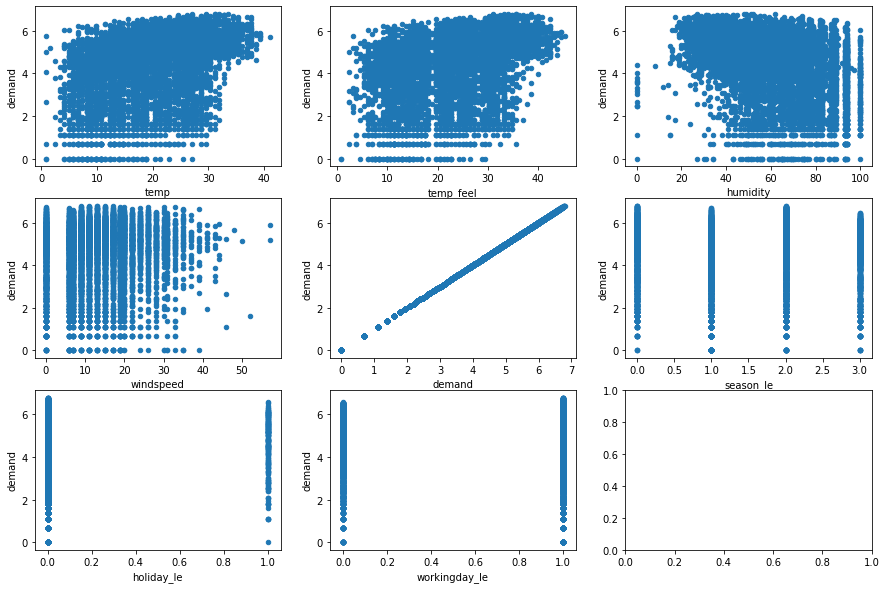

In [175]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
for idx, feature in enumerate(data.columns[:-1]):
    data.plot(feature, "demand", subplots=True, kind="scatter", ax=axes[idx // 3, idx % 3])

In [176]:
# We need to predict the number of rentals depending on the time and weather conditions, so we will solve the regression problem.

In [177]:
# Let's more rigorously evaluate the level of linear relationship between the features and the target variable. 
# A good measure of a linear relationship between two vectors is the Pearson correlation. 
# In pandas, it can be calculated using two dataframe methods: corr and corrwith. 
# The df.corr method calculates the correlation matrix of all features from the dataframe. 
# The df.corrwith method needs to give one more dataframe as an argument, and then it will calculate pairwise correlations between features from df and this dataframe.

In [178]:
data.loc[:, data.columns != 'demand'].corrwith(data.demand)

temp             0.394451
temp_feel        0.390328
humidity        -0.334264
windspeed        0.125891
season_le        0.005870
holiday_le       0.004160
workingday_le   -0.020893
weather_le      -0.056475
dtype: float64

In [140]:
# The sample contains features that correlate with the target, 
# which means that the problem can be solved by linear methods. 
# True, this correlation is small and one could do a combination of features, 
# but there is no time for this :(
# Let's look at the averages of features (mean method) to estimate the scale of features and the proportion of 1 for binary features.

In [179]:
data.mean()

temp             20.115051
temp_feel        23.559089
humidity         60.843981
windspeed        13.030484
demand            4.453294
season_le         1.399722
holiday_le        0.027140
workingday_le     0.687404
weather_le        0.567850
dtype: float64

In [142]:
# Features have different scales, which means that for further work it is better for us to normalize the matrix of features-objects.

In [143]:
# To begin with, let's perform scaling, or standardization of features: 
# subtract its mean from each feature and divide by the standard deviation. 
# This can be done using the scale method.
# In addition, you need to mix the sample, this will be required for cross-validation.

In [180]:
data_shuffled = shuffle(data, random_state=123)
X = scale(data_shuffled[data_shuffled.columns[:-1]])
y = data_shuffled["demand"]

In [181]:
# Let's train linear regression on our data and look at the feature weights.

In [182]:
linear_regressor = LinearRegression()
linear_regressor.fit(X, y)
for i in zip(linear_regressor.coef_, data.columns[:-1]):
    print(i)

(-4.124872608849889e-15, 'temp')
(4.9960036108132044e-15, 'temp_feel')
(9.71445146547012e-17, 'humidity')
(-1.0234868508263162e-16, 'windspeed')
(1.499647069889063, 'demand')
(-2.914335439641036e-16, 'season_le')
(-9.6710833785707e-17, 'holiday_le')
(3.5561831257524545e-17, 'workingday_le')


In [147]:
# It seems that there are no linearly dependent (collinear) features, 
# because no weights are observed that are significantly larger in modulus than all the others.

In [148]:
# Let's divide the training sample into two datasets to assess the quality of model training, 
# selecting 1/3 for validation.

In [183]:
trn_data, tst_data, trn_labels, tst_labels = model_selection.train_test_split(X, y, test_size = 0.3)

In [184]:
# OK, lets get the predictions of the regression model and evaluate its quality with MAE metric

In [185]:
predictions = linear_regressor.predict(tst_data)

In [186]:
print ("MAE = " + str(metrics.mean_absolute_error(tst_labels, predictions)))

MAE = 9.943602321665943e-16


In [187]:
# Looks good. Let's get the predictions of our model for a given test sample.

In [188]:
predictions = linear_regressor.predict(test_data)
print(predictions)

[4.45329432 4.45329432 4.45329432 ... 5.95294139 5.95294139 5.95294139]


In [189]:
# Let's create the resulting dataset for subsequent export to CSV.

In [196]:
result['demand'] = predictions.round(1)
result

,id,demand
0,8709,4.5
1,8710,4.5
2,8712,4.5
3,8713,4.5
4,8714,4.5
...,...,...
1787,10882,6.0
1788,10883,6.0
1789,10884,6.0
1790,10885,6.0


In [197]:
#Description
result.describe()

,id,demand
count,1792.000000,1792.000000
mean,9806.661830,5.447545
std,629.446046,0.723718
min,8709.000000,4.500000
25%,9261.750000,4.500000
50%,9811.500000,6.000000
75%,10354.250000,6.000000
max,10886.000000,6.000000


In [198]:
# Export to CSV file

In [199]:
result.to_csv('submissions.csv', index=False)



**Identify the most important features of the model for management.**

> #### Task:
- **Visualize the top 20 features and their feature importance.**


> #### Task:
- **Submit the predictions on the test dataset using the optimized model** <br/>
    For each record in the test set (`test.csv`), predict the value of the `demand` variable. Submit a CSV file with a header row and one row per test entry.
    
The file (`submissions.csv`) should have exactly 2 columns:
   - **id**
   - **demand**

In [ ]:
#Submission
submission_df.to_csv('submissions.csv',index=False)

---